In [79]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [80]:
words = open('names.txt', 'r').read().splitlines()
print(len(words), 'words loaded.')
print(max(len(w) for w in words), 'is the longest word.')
words[:8]

32033 words loaded.
15 is the longest word.


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [81]:
#build a vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print('vocab', itos)
print('vocab size:', vocab_size)

vocab {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
vocab size: 27


In [82]:
# build the dataset

import random

def build_train_valid_test(words, block_size, stoi, train_ratio, valid_ratio, test_ratio):
    random.seed(42)
    random.shuffle(words)
    n1 = int(train_ratio*len(words))
    n2 = int((train_ratio + valid_ratio)*len(words))

    X_train, Y_train = build_dataset(words[:n1], block_size, stoi)
    X_valid, Y_valid = build_dataset(words[n1:n2], block_size, stoi)
    X_test, Y_test = build_dataset(words[n2:], block_size, stoi)

    return X_train, Y_train, X_valid, Y_valid, X_test, Y_test

def build_dataset(words, block_size, stoi):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    return torch.tensor(X), torch.tensor(Y)

block_size = 8 # context length - how many charachters do we take to predict the next one
X_train, Y_train, X_valid, Y_valid, X_test, Y_test = build_train_valid_test(words, block_size, stoi, 0.8, 0.1, 0.1)

In [83]:
for x,y in zip(X_train[:20], Y_train[:20]):
    context = ''.join(itos[int(i)] for i in x)
    target = itos[int(y)]
    print(f'{context} -> {target}')

........ -> y
.......y -> u
......yu -> h
.....yuh -> e
....yuhe -> n
...yuhen -> g
..yuheng -> .
........ -> d
.......d -> i
......di -> o
.....dio -> n
....dion -> d
...diond -> r
..diondr -> e
.diondre -> .
........ -> x
.......x -> a
......xa -> v
.....xav -> i
....xavi -> e


In [84]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / (fan_in**0.5)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
            x_mean = x.mean(dim, keepdim=True) # batch mean
            x_var = x.var(dim, keepdim=True)#, unbiased=True) # batch variance
        else:
            x_mean = self.running_mean
            x_var = self.running_var
        
        xhat = (x - x_mean) / torch.sqrt(x_var + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # scale and shift

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * x_mean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * x_var

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, x):
        self.out = self.weight[x]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [85]:
torch.manual_seed(42) # for reproducibility
n_embed = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP

model = Sequential([
    Embedding(vocab_size, n_embed),
    FlattenConsecutive(2), Linear(n_embed  * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# parameters init
with torch.no_grad():
    model.layers[-1].weight *= 0.1 # last layer: make less confident

parameters = model.parameters()
print('number of parameters in the model:', sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

number of parameters in the model: 76579


In [86]:
batch_size = 32
iterations = 100000

lrs = [0.1, 0.03, 0.01, 0.003]
epochs = len(lrs)
iterations_per_epoch = iterations // epochs

losses = []

for epoch in range(epochs):
    learning_rate = lrs[epoch]

    for iter in range(iterations_per_epoch):

        # minibatch construct
        ix = torch.randint(0, X_train.shape[0], (batch_size,))
        Xb, Yb = X_train[ix], Y_train[ix]

        # forward pass
        logits = model(Xb)
        loss = F.cross_entropy(logits, Yb) # loss function

        # backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # update
        for p in parameters:
            p.data += -learning_rate * p.grad

        #track stats
        step = iter + epoch * iterations_per_epoch
        if step % (iterations // 20) == 0:
            print(f'{step:7d}/{iterations:7d}: {loss.item():.4f} lr={learning_rate}')
        losses.append(loss.log10().item())

      0/ 100000: 3.3167 lr=0.1
   5000/ 100000: 2.1904 lr=0.1
  10000/ 100000: 2.0576 lr=0.1
  15000/ 100000: 1.8216 lr=0.1
  20000/ 100000: 2.0723 lr=0.1
  25000/ 100000: 2.2261 lr=0.03
  30000/ 100000: 2.4684 lr=0.03
  35000/ 100000: 1.6697 lr=0.03
  40000/ 100000: 2.1120 lr=0.03
  45000/ 100000: 2.0020 lr=0.03
  50000/ 100000: 1.7270 lr=0.01
  55000/ 100000: 1.7064 lr=0.01
  60000/ 100000: 2.3356 lr=0.01
  65000/ 100000: 1.9422 lr=0.01
  70000/ 100000: 1.8617 lr=0.01
  75000/ 100000: 1.4340 lr=0.003
  80000/ 100000: 1.7200 lr=0.003
  85000/ 100000: 1.8888 lr=0.003
  90000/ 100000: 2.0149 lr=0.003
  95000/ 100000: 1.8934 lr=0.003


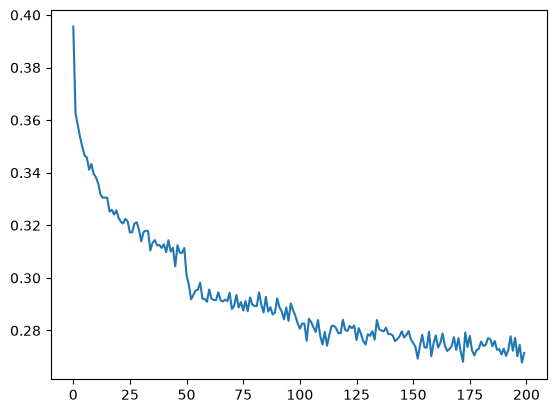

In [90]:
plt.plot(torch.tensor(losses).view(-1, 500).mean(1))

In [91]:
# put layers into eval mode (needed for batchnorm espessially)
for layer in model.layers:
    layer.training = False

In [92]:
# evaluate the loss
@torch.no_grad() # to let know pytorch that this code requires no gradients calculations
def split_loss(split, datasets, moodel):
    X_train, Y_train, X_valid, Y_valid, X_test, Y_test = datasets
    x, y = {
        'train': (X_train, Y_train),
        'valid': (X_valid, Y_valid),
        'test': (X_test, Y_test),
    }[split]

    # forward pass
    logits = model(x)
    loss = F.cross_entropy(logits, y)

    print(split, loss.item())

split_loss('train', [X_train, Y_train, X_valid, Y_valid, X_test, Y_test], model)
split_loss('valid', [X_train, Y_train, X_valid, Y_valid, X_test, Y_test], model)

train 1.8625682592391968
valid 1.9936003684997559


In [42]:
# sample from the model

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # break if we sampled the end-of-word character
        if ix == 0:
            break
        
    print(''.join(itos[i] for i in out))

staraj.
markines.
uriyanah.
zxon.
catalynn.
damery.
jalyliah.
lanniesh.
remi.
mersie.
izabella.
prospe.
nakori.
jamar.
orab.
olivanne.
apollee.
kenda.
alonnie.
jeridana.
